# Klasyfikacja leków i generowanie ich pochodnych na podstawie deskryptorów molekularnych i metod uczenia maszynowego.

# 0. Przygotowanie środowiska

## 0.1 Importy bibliotek, pomocnicze zmienne globalne

In [2]:
import warnings
from pathlib import Path
import hashlib
import pickle

import numpy as np
import pandas as pd

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Descriptors, Lipinski, Crippen, rdMolDescriptors, Draw
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.rdChemReactions import ReactionFromSmarts
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.utils.validation import validate_data
from xgboost import XGBClassifier

from deslib.base import BaseDS
from deslib.des.des_p import DESP
from deslib.des.knora_e import KNORAE
from deslib.des.knora_u import KNORAU

RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")

SEED = 8

DESCRIPTOR_COLS = [
    "MolWt", "LogP", "TPSA", "HBD", "HBA",
    "RotBonds", "RingCount", "FractionCSP3", "Ro5_violations",
]

ISOSTERE_ID_COLS  = ["original_smiles", "reaction_type", "isostere_smiles"]
TAG_EVAL_ID_COLS  = ["original_smiles", "original_tag", "reaction_type", "isostere_smiles"]
DES_RANKING_SUMMARY_COLS = [
    "DES_methods_preserving_original_tag_count",
    "DES_all_methods_preserve_original_tag",
    "DES_mean_original_tag_proba_original",
    "DES_mean_original_tag_proba_isostere",
    "delta_DES_mean_original_tag_proba",
    "DES_best_delta_original_tag_proba",
]

## 0.2 Ustawienia pamięci cache

In [3]:
MODEL_CACHE_DIR = Path("model_cache")
MODEL_CACHE_DIR.mkdir(exist_ok=True)

# True = ponowne trenowanie modeli
FORCE_RETRAIN_MODELS = False
FORCE_RETRAIN_DESLIB  = False

# 1. Dane

## 1.0.1 Funkcje pomocnicze - cząsteczki i fragmenty

In [4]:
def sanitize_smiles(smiles, desalt=False, uncharge=False):
    if not isinstance(smiles, str):
        return None

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        if desalt:
            fragment_chooser = rdMolStandardize.LargestFragmentChooser()
            mol = fragment_chooser.choose(mol)

        if uncharge:
            uncharger = rdMolStandardize.Uncharger()
            mol = uncharger.uncharge(mol)

        Chem.SanitizeMol(mol)
        return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)

    except Exception:
        return None

def generate_mol(smiles):
    if not isinstance(smiles, str):
        return None

    try:
        return Chem.MolFromSmiles(smiles)
    except Exception:
        return None

def generate_fp(mol, radius=2, nBits=2048):
    if mol is None:
        return np.zeros(nBits)

    try:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
        return np.array(fp)
    except Exception:
        return np.zeros(nBits)

def calculate_rdkit_descriptors(mol):
    if mol is None:
        return {col: np.nan for col in DESCRIPTOR_COLS}

    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)

    return {
        "MolWt": mw,
        "LogP": logp,
        "TPSA": tpsa,
        "HBD": hbd,
        "HBA": hba,
        "RotBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": Lipinski.RingCount(mol),
        "FractionCSP3": Lipinski.FractionCSP3(mol),
        "Ro5_violations": sum([
            mw > 500,
            logp > 5,
            hbd > 5,
            hba > 10,
        ]),
    }

def split_main_and_side_fragments(smiles):
    mol = generate_mol(smiles)
    if mol is None:
        return None, []

    try:
        frags = Chem.GetMolFrags(mol, asMols=True)
        frags = sorted(frags, key=lambda m: m.GetNumHeavyAtoms(), reverse=True)

        main_frag = frags[0]
        side_frags = frags[1:]

        return main_frag, side_frags
    except Exception:
        return None, []

def combine_product_with_side_fragments(product_mol, side_frags):
    try:
        product_smiles = Chem.MolToSmiles(product_mol, isomericSmiles=True, canonical=True)
        side_smiles = [
            Chem.MolToSmiles(frag, isomericSmiles=True, canonical=True)
            for frag in side_frags
        ]

        combined_smiles = ".".join([product_smiles] + side_smiles)
        return sanitize_smiles(combined_smiles)
    except Exception:
        return None
    
def get_bemis_murcko_scaffold(mol):
    if mol is None:
        return None
    try:
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
        return scaffold if scaffold else "ACYCLIC"
    except Exception:
        return None

## 1.0.2 Funkcje pomocnicze - cechy i kolumny 

In [39]:
def build_features(df):
    """Łączy fingerprint Morgana z deskryptorami RDKit."""
    X_fp = np.stack(df["fingerprint"].values)
    X_desc = (
        df["mol"]
        .apply(calculate_rdkit_descriptors)
        .apply(pd.Series)
        [DESCRIPTOR_COLS]
        .replace([np.inf, -np.inf], np.nan)
    )

    X_desc = X_desc.fillna(X_desc.median(numeric_only=True))

    return np.hstack([X_fp, X_desc.to_numpy(dtype=float)])


def descriptor_comparison_cols(cols=DESCRIPTOR_COLS):
    return [
        col
        for descriptor in cols
        for col in (
            f"{descriptor}_original",
            f"{descriptor}_isostere",
            f"delta_{descriptor}",
        )
    ]


def model_prediction_cols(model_names):
    predictions = [f"Predykcja_{name}" for name in model_names]
    changes = [f"Zmiana aktywnosci {name}" for name in model_names]

    return predictions, changes


def des_pred_col(name, mol_type):
    return f"Predykcja_{mol_type}_DES_{name}"


def des_change_col(name):
    return f"Zmiana aktywnosci DES_{name}"


def des_proba_col(name, mol_type):
    return f"DES_{name}_original_tag_proba_{mol_type}"


def des_delta_col(name):
    return f"delta_DES_{name}_original_tag_proba"


def des_ranking_cols(model_names):
    per_model_cols = [
        col
        for name in model_names
        for col in (
            des_pred_col(name, "isostere"),
            des_change_col(name),
            des_delta_col(name),
        )
    ]

    return [
        "original_smiles",
        "original_tag",
        "reaction_type",
        "isostere_smiles",
        *DES_RANKING_SUMMARY_COLS,
        *per_model_cols,
    ]

## 1.1 Wczytanie danych

In [5]:
data = pd.read_csv("/Users/franek/Projects/licencjat_git/data/all_chem_df.csv")

## 1.2 Oczyszczenie danych

In [7]:
data["tags"] = data["tags"].fillna("").str.split()
data = data.drop(columns=["image_name", "Col3"], errors="ignore")

# Pozostawiamy jedynie single-label cząsteczki
data = (
    data[data["tags"].apply(len) == 1]
    .assign(tags=lambda df: df["tags"].apply(lambda x: x[0]))
    .reset_index(drop=True)
)

data["smiles"]      = data["smiles"].apply(sanitize_smiles)
data["mol"]         = data["smiles"].apply(generate_mol)
data["fingerprint"] = data["mol"].apply(generate_fp)
data["scaffold"]    = data["mol"].apply(get_bemis_murcko_scaffold)

data = data.dropna(subset=["scaffold"]).reset_index(drop=True)

print(f"Wczytano {len(data)} czasteczek, liczba klas: {data['tags'].nunique()}.")

Wczytano 6970 cząsteczek, liczba klas: 12.


# 2. Generowanie bioizosterów

## 2.0 Definiowanie słownika reakcji

In [9]:
FUNCTIONAL_GROUP_SMARTS = {
    "Cl_to_F": "[Cl:1]>>[F:1]",
    "F_to_Cl": "[F:1]>>[Cl:1]",
    "Cl_to_Br": "[Cl:1]>>[Br:1]",
    "Br_to_Cl": "[Br:1]>>[Cl:1]",
    "Aromatic_H_to_F": "[cH:1]>>[c:1][F]",
    "OH_to_NH2": "[O;H1:1]>>[N;H2:1]",
    "NH2_to_OH": "[N;H2:1]>>[O;H1:1]",
    "OH_to_SH": "[O;H1:1]>>[S;H1:1]",
    "SH_to_OH": "[S;H1:1]>>[O;H1:1]",
    "OH_to_F": "[O;H1:1]>>[F:1]",
    "COOH_to_CONH2": "[C:1](=[O:2])[O;H1:3]>>[C:1](=[O:2])[N;H2:3]",
    "CONH2_to_COOH": "[C:1](=[O:2])[N;H2:3]>>[C:1](=[O:2])[O;H1:3]",
    "Ester_to_Amide": "[C:1](=[O:2])[O:3][C:4]>>[C:1](=[O:2])[N:3][C:4]",
    "Amide_to_Ester": "[C:1](=[O:2])[N:3][C:4]>>[C:1](=[O:2])[O:3][C:4]",
    "Amide_to_Thioamide": "[C:1](=[O:2])[N:3]>>[C:1](=[S:2])[N:3]",
    "Thioamide_to_Amide": "[C:1](=[S:2])[N:3]>>[C:1](=[O:2])[N:3]",
    "Ketone_to_Alcohol": "[C:1](=[O:2])[C:3]>>[C:1]([O;H1:2])[C:3]",
    "Aldehyde_to_Alcohol": "[C;H1:1](=[O:2])>>[C:1]([O;H1:2])",
    "Methyl_to_Chloro": "[CH3:1]>>[Cl:1]",
    "Chloro_to_Methyl": "[Cl:1]>>[CH3:1]",
    "Ether_to_Thioether": "[O:1]([C:2])[C:3]>>[S:1]([C:2])[C:3]",
    "Thioether_to_Ether": "[S:1]([C:2])[C:3]>>[O:1]([C:2])[C:3]",
    "Ether_to_Amine": "[O:1]([C:2])[C:3]>>[N:1]([C:2])[C:3]",
    "Amine_to_Ether": "[N:1]([C:2])[C:3]>>[O:1]([C:2])[C:3]",
}

SCAFFOLD_SMARTS = {
    "Aromatic_CH_to_N": "[cH:1]>>[n:1]",
    "Aromatic_N_to_CH": "[n:1]>>[cH:1]",
    "Aromatic_S_to_O": "[s:1]>>[o:1]",
    "Aromatic_O_to_S": "[o:1]>>[s:1]",
    "Aromatic_CH_to_Sat_CH2": "[cH:1]>>[CH2:1]",
    "Saturated_CH2_to_Arom_CH": "[CH2:1]>>[cH:1]",
}

reaction_smarts = {
    **FUNCTIONAL_GROUP_SMARTS,
    **SCAFFOLD_SMARTS,
}

ALL_REACTIONS = {
    name: ReactionFromSmarts(smarts)
    for name, smarts in reaction_smarts.items()
}

## 2.1 Wybór cząsteczek reprezentatywnych

In [10]:
smiles_arr = data["smiles"].to_numpy()
fp_arr     = np.stack(data["fingerprint"].values)

rows = []
for tag, positions in data.groupby("tags").groups.items():
    positions = list(positions)
    fps = fp_arr[positions]
    n   = len(fps)

    sim_sums = np.ones(n, dtype=float)   #czasteczka podobna do samej siebie = 1.0
    if n > 1:
        for i in range(1, n):
            inter   = fps[:i] @ fps[i]
            sum_a   = fps[:i].sum(axis=1)
            sum_b   = fps[i].sum()
            sims    = inter / (sum_a + sum_b - inter)
            sim_sums[i]   += sims.sum()
            sim_sums[:i]  += sims
    
    #wybor czasteczek najbardziej srednio podobnych w obrebie klasy
    mean_tanimoto = sim_sums / n
    for local_idx in np.argsort(-mean_tanimoto)[:min(5, n)]:
        rows.append({
            "tags":                 tag,
            "original_smiles":      smiles_arr[positions[local_idx]],
            "mean_tanimoto_to_tag": mean_tanimoto[local_idx],
        })

top5_by_tag = pd.DataFrame(rows)
print(f"Wybrano {len(top5_by_tag)} cząsteczek reprezentatywnych.")

Wybrano 60 cząsteczek reprezentatywnych.


## 2.2 Generowanie bioizosterów

In [34]:
reaction_results = []

for _, row in top5_by_tag.iterrows():
    original_smiles = row["original_smiles"]

    if not isinstance(original_smiles, str) or not original_smiles.strip():
        continue

    main_frag, side_frags = split_main_and_side_fragments(original_smiles)

    if main_frag is None:
        continue

    for reaction_type, reaction in ALL_REACTIONS.items():
        generated_smiles = set()

        for products in reaction.RunReactants((main_frag,)):
            isostere_smiles = combine_product_with_side_fragments(products[0], side_frags)

            if isostere_smiles and isostere_smiles != original_smiles:
                generated_smiles.add(isostere_smiles)

        for isostere_smiles in generated_smiles:
            reaction_results.append({
                "original_tag": row["tags"],
                "original_smiles": original_smiles,
                "mean_tanimoto_to_tag": row["mean_tanimoto_to_tag"],
                "reaction_type": reaction_type,
                "isostere_smiles": isostere_smiles,
            })


isosteres_data = (
    pd.DataFrame(reaction_results)
    .drop_duplicates(
        subset=["original_smiles", "reaction_type", "isostere_smiles"]
    )
    .reset_index(drop=True)
)

isosteres_data["mol"] = isosteres_data["isostere_smiles"].apply(generate_mol)
isosteres_data["fingerprint"] = isosteres_data["mol"].apply(generate_fp)

print(f"Wygenerowano {len(isosteres_data)} unikatowych bioizosterow.")

Wygenerowano 996 unikatowych bioizosterow.


# 3. Trening modeli

In [18]:
X = build_features(data)

le = LabelEncoder()
y = le.fit_transform(data["tags"])
groups = data["scaffold"].values

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

train_scaffolds = set(data.iloc[train_idx]["scaffold"])
test_scaffolds = set(data.iloc[test_idx]["scaffold"])
common_scaffolds = train_scaffolds & test_scaffolds

print(f"Rozmiar zestawu treningowego: {X_train.shape[0]}") 
print(f"Rozmiar zestawu testowego: {X_test.shape[0]}") 
print(f"Liczba cech: {X.shape[1]}")
print(
    "Scaffoldy train/test/wspólne: "
    f"{len(train_scaffolds)} / {len(test_scaffolds)} / {len(common_scaffolds)}"
)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=-1,
    ),
    "SVM": make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            probability=True,
            decision_function_shape="ovr",
            random_state=SEED,
        ),
    ),
    "XGBoost": XGBClassifier(
        eval_metric="mlogloss",
        random_state=SEED,
    ),
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
}

data_signature = hashlib.sha1(
    data[["smiles", "tags"]]
    .astype(str)
    .to_csv(index=False, header=False)
    .encode()
).hexdigest()[:12]

model_cache_path = MODEL_CACHE_DIR / f"models_seed{SEED}_{data_signature}.pkl"

def cache_is_valid(payload):
    expected_values = {
        "seed": SEED,
        "descriptor_cols": DESCRIPTOR_COLS,
        "data_signature": data_signature,
        "classes": list(le.classes_),
        "X_shape": X.shape,
    }

    return (
        all(payload.get(key) == value for key, value in expected_values.items())
        and np.array_equal(payload.get("train_idx"), train_idx)
        and np.array_equal(payload.get("test_idx"), test_idx)
    )

trained_models = None
model_metrics = None

if model_cache_path.exists() and not FORCE_RETRAIN_MODELS:
    with open(model_cache_path, "rb") as file:
        payload = pickle.load(file)

    if cache_is_valid(payload):
        trained_models = payload["trained_models"]
        model_metrics = payload["model_metrics"]
        print(f"[cache] Wczytano modele: {model_cache_path}")

if trained_models is None:
    trained_models = {}
    model_metrics = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        trained_models[name] = model
        model_metrics[name] = {
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "macro_f1": f1_score(y_test, y_pred, average="macro"),
        }

    payload = {
        "seed": SEED,
        "descriptor_cols": DESCRIPTOR_COLS,
        "data_signature": data_signature,
        "classes": list(le.classes_),
        "X_shape": X.shape,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "trained_models": trained_models,
        "model_metrics": model_metrics,
    }

    with open(model_cache_path, "wb") as file:
        pickle.dump(payload, file)

    print(f"[cache] Zapisano modele: {model_cache_path}")

for name, metrics in model_metrics.items():
    print(
        f"{name}: "
        f"acc={metrics['accuracy']:.4f} "
        f"bal_acc={metrics['balanced_accuracy']:.4f} "
        f"macro_F1={metrics['macro_f1']:.4f}"
    )

class_to_idx = {
    label: idx
    for idx, label in enumerate(le.classes_)
}

Train: 5576 | Test: 1394 | Cechy: 2057
Scaffoldy train/test/wspólne: 1775 / 430 / 0
[cache] Zapisano modele: model_cache/models_seed8_3cc415afa9d6.pkl
Random Forest: acc=0.5976 bal_acc=0.3622 macro_F1=0.4063
SVM: acc=0.5760 bal_acc=0.3228 macro_F1=0.3697
XGBoost: acc=0.6169 bal_acc=0.3921 macro_F1=0.4357
Logistic Regression: acc=0.5653 bal_acc=0.4292 macro_F1=0.4347


## 3.1 Powstała tabela predyckji klasy izosterów

In [19]:
X_isostere = build_features(isosteres_data)

isosteres_data["original_tag"] = (
    isosteres_data["original_smiles"].map(dict(zip(data["smiles"], data["tags"])))
)

pred_cols, change_cols = model_prediction_cols(trained_models)

for name, model in trained_models.items():
    pred_col   = f"Predykcja_{name}"
    change_col = f"Zmiana aktywnosci {name}"
    preds = le.inverse_transform(model.predict(X_isostere))
    isosteres_data[pred_col]   = preds
    isosteres_data[change_col] = isosteres_data["original_tag"] != isosteres_data[pred_col]

isosteres_data[[*ISOSTERE_ID_COLS, "original_tag", *pred_cols, *change_cols]]

,original_smiles,reaction_type,isostere_smiles,original_tag,Predykcja_Random Forest,Predykcja_SVM,Predykcja_XGBoost,Predykcja_Logistic Regression,Zmiana aktywnosci Random Forest,Zmiana aktywnosci SVM,Zmiana aktywnosci XGBoost,Zmiana aktywnosci Logistic Regression
0,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,Aromatic_H_to_F,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,antiinfective,antiinfective,antiinfective,antiinfective,False,False,False,False
1,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,OH_to_NH2,COCC1=C(C(N)=O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,antiinfective,antiinfective,antiinfective,antiinfective,False,False,False,False
2,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,NH2_to_OH,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,antiinfective,antiinfective,antiinfective,antiinfective,False,False,False,False
3,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,OH_to_SH,COCC1=C(C(=O)S)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,antiinfective,antiinfective,antiinfective,antiinfective,False,False,False,False
4,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,OH_to_F,COCC1=C(C(=O)F)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,antiinfective,antiinfective,antiinfective,antiinfective,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
991,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,Aromatic_CH_to_N,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccncc2[...,urological,urological,urological,urological,urological,False,False,False,False
992,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,Aromatic_CH_to_N,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,urological,urological,urological,urological,urological,False,False,False,False
993,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,Aromatic_CH_to_N,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,urological,urological,urological,urological,urological,False,False,False,False
994,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,Aromatic_CH_to_N,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2cnccc2[...,urological,urological,urological,urological,urological,False,False,False,False


## 3.2 Porównanie właściwości fizykochemicznych izosterów

In [35]:
def add_descriptor_cols(df: pd.DataFrame, smiles_col: str, suffix: str) -> pd.DataFrame:
    desc = (
        df[smiles_col]
        .apply(generate_mol)
        .apply(calculate_rdkit_descriptors)
        .apply(pd.Series)
        [DESCRIPTOR_COLS]
        .add_suffix(f"_{suffix}")
    )
    return pd.concat([df, desc], axis=1)

isosteres_data = add_descriptor_cols(isosteres_data, "original_smiles",  "original")
isosteres_data = add_descriptor_cols(isosteres_data, "isostere_smiles", "isostere")

for d in DESCRIPTOR_COLS:
    isosteres_data[f"delta_{d}"] = (
        isosteres_data[f"{d}_isostere"] - isosteres_data[f"{d}_original"]
    )

isosteres_data[[*ISOSTERE_ID_COLS, *descriptor_comparison_cols()]]

,original_smiles,reaction_type,isostere_smiles,MolWt_original,MolWt_isostere,delta_MolWt,LogP_original,LogP_isostere,delta_LogP,TPSA_original,...,delta_RotBonds,RingCount_original,RingCount_isostere,delta_RingCount,FractionCSP3_original,FractionCSP3_isostere,delta_FractionCSP3,Ro5_violations_original,Ro5_violations_isostere,delta_Ro5_violations
0,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,Aromatic_H_to_F,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,427.464,445.454,17.990,-0.5392,-0.4001,0.1391,156.44,...,0.0,3.0,3.0,0.0,0.400000,0.400000,0.000000,0.0,0.0,0.0
1,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,OH_to_NH2,COCC1=C(C(N)=O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,427.464,426.480,-0.984,-0.5392,-1.1385,-0.5993,156.44,...,0.0,3.0,3.0,0.0,0.400000,0.400000,0.000000,0.0,0.0,0.0
2,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,NH2_to_OH,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,427.464,428.448,0.984,-0.5392,-0.4158,0.1234,156.44,...,0.0,3.0,3.0,0.0,0.400000,0.400000,0.000000,0.0,0.0,0.0
3,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,OH_to_SH,COCC1=C(C(=O)S)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,427.464,443.532,16.068,-0.5392,-0.1674,0.3718,156.44,...,0.0,3.0,3.0,0.0,0.400000,0.400000,0.000000,0.0,0.0,0.0
4,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,OH_to_F,COCC1=C(C(=O)F)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,427.464,429.455,1.991,-0.5392,-0.1277,0.4115,156.44,...,0.0,3.0,3.0,0.0,0.400000,0.400000,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,Aromatic_CH_to_N,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccncc2[...,480.561,481.549,0.988,3.8007,3.1957,-0.6050,107.38,...,0.0,6.0,6.0,0.0,0.444444,0.461538,0.017094,0.0,0.0,0.0
992,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,Aromatic_CH_to_N,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,480.561,481.549,0.988,3.8007,3.1957,-0.6050,107.38,...,0.0,6.0,6.0,0.0,0.444444,0.461538,0.017094,0.0,0.0,0.0
993,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,Aromatic_CH_to_N,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,480.561,481.549,0.988,3.8007,3.1957,-0.6050,107.38,...,0.0,6.0,6.0,0.0,0.444444,0.461538,0.017094,0.0,0.0,0.0
994,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,Aromatic_CH_to_N,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2cnccc2[...,480.561,481.549,0.988,3.8007,3.1957,-0.6050,107.38,...,0.0,6.0,6.0,0.0,0.444444,0.461538,0.017094,0.0,0.0,0.0


# 4. Deslib - dynamiczny wybór klasyfikatorów

In [26]:
#sposób na obejście błędów między DESlib i scikit-learn
if not hasattr(BaseDS, "_validate_data"):
    def _validate_data(self, X, y=None, **kwargs):
        return validate_data(self, X, y, **kwargs)

    BaseDS._validate_data = _validate_data


des_cache_path = MODEL_CACHE_DIR / f"deslib_seed{SEED}_{data_signature}.pkl"


def des_cache_is_valid(payload):
    expected_values = {
        "seed": SEED,
        "data_signature": data_signature,
        "X_shape": X.shape,
        "classes": list(le.classes_),
    }

    return all(payload.get(key) == value for key, value in expected_values.items())


des_models = None

if des_cache_path.exists() and not FORCE_RETRAIN_DESLIB:
    with open(des_cache_path, "rb") as file:
        des_payload = pickle.load(file)

    if des_cache_is_valid(des_payload):
        des_models = des_payload["des_models"]
        print(f"[cache] Wczytano DESlib: {des_cache_path}")


if des_models is None:
    try:
        X_base, X_dsel, y_base, y_dsel = train_test_split(
            X_train,
            y_train,
            test_size=0.30,
            stratify=y_train,
            random_state=SEED,
        )
    except ValueError:
        X_base, X_dsel, y_base, y_dsel = train_test_split(
            X_train,
            y_train,
            test_size=0.30,
            random_state=SEED,
        )

    base_pool = []

    for model in models.values():
        base_model = clone(model)
        base_model.fit(X_base, y_base)
        base_pool.append(base_model)

    des_models = {
        "KNORAE": KNORAE(pool_classifiers=base_pool, k=7, random_state=SEED),
        "KNORAU": KNORAU(pool_classifiers=base_pool, k=7, random_state=SEED),
        "DESP": DESP(pool_classifiers=base_pool, k=7, random_state=SEED),
    }

    for des_model in des_models.values():
        des_model.fit(X_dsel, y_dsel)

    des_payload = {
        "seed": SEED,
        "data_signature": data_signature,
        "X_shape": X.shape,
        "classes": list(le.classes_),
        "des_models": des_models,
    }

    with open(des_cache_path, "wb") as file:
        pickle.dump(des_payload, file)

    print(f"[cache] Zapisano DESlib: {des_cache_path}")


for name, des_model in des_models.items():
    y_pred = des_model.predict(X_test)

    print(
        f"{name}: "
        f"acc={accuracy_score(y_test, y_pred):.4f} "
        f"bal_acc={balanced_accuracy_score(y_test, y_pred):.4f} "
        f"macro_F1={f1_score(y_test, y_pred, average='macro'):.4f}"
    )

[cache] Zapisano DESlib: model_cache/deslib_seed8_3cc415afa9d6.pkl
KNORAE: acc=0.6047 bal_acc=0.3683 macro_F1=0.4178
KNORAU: acc=0.6033 bal_acc=0.3652 macro_F1=0.4122
DESP: acc=0.5976 bal_acc=0.3572 macro_F1=0.4087


# 5. Klasyfikacja powstałych bioizosterów

In [37]:
def features_for_smiles(smiles_series):
    df = pd.DataFrame({
        "mol": smiles_series.apply(generate_mol),
    })

    df["fingerprint"] = df["mol"].apply(generate_fp)

    return build_features(df)


def proba_for_original_class(probas, class_ids):
    result = np.full(len(class_ids), np.nan)

    for i, class_id in enumerate(class_ids):
        if not pd.isna(class_id):
            result[i] = probas[i, int(class_id)]

    return result


X_original_eval = features_for_smiles(isosteres_data["original_smiles"])
original_class_ids = isosteres_data["original_tag"].map(class_to_idx)

model_eval_df = isosteres_data[TAG_EVAL_ID_COLS].copy()

for name, des_model in des_models.items():
    original_pred_col = des_pred_col(name, "original")
    isostere_pred_col = des_pred_col(name, "isostere")
    change_col = des_change_col(name)

    original_predictions = des_model.predict(X_original_eval)
    isostere_predictions = des_model.predict(X_isostere)

    model_eval_df[original_pred_col] = le.inverse_transform(original_predictions)
    model_eval_df[isostere_pred_col] = le.inverse_transform(isostere_predictions)
    model_eval_df[change_col] = (
        model_eval_df["original_tag"] != model_eval_df[isostere_pred_col]
    )

    if hasattr(des_model, "predict_proba"):
        original_proba_col = des_proba_col(name, "original")
        isostere_proba_col = des_proba_col(name, "isostere")
        delta_col = des_delta_col(name)

        original_probas = des_model.predict_proba(X_original_eval)
        isostere_probas = des_model.predict_proba(X_isostere)

        model_eval_df[original_proba_col] = proba_for_original_class(
            original_probas,
            original_class_ids,
        )
        model_eval_df[isostere_proba_col] = proba_for_original_class(
            isostere_probas,
            original_class_ids,
        )
        model_eval_df[delta_col] = (
            model_eval_df[isostere_proba_col] - model_eval_df[original_proba_col]
        )


change_cols = [des_change_col(name) for name in des_models]
delta_cols = [des_delta_col(name) for name in des_models]
original_proba_cols = [des_proba_col(name, "original") for name in des_models]
isostere_proba_cols = [des_proba_col(name, "isostere") for name in des_models]

preserved_count_col = "DES_methods_preserving_original_tag_count"
all_preserved_col = "DES_all_methods_preserve_original_tag"
mean_original_proba_col = "DES_mean_original_tag_proba_original"
mean_isostere_proba_col = "DES_mean_original_tag_proba_isostere"
mean_delta_col = "delta_DES_mean_original_tag_proba"
best_delta_col = "DES_best_delta_original_tag_proba"

model_eval_df[preserved_count_col] = (~model_eval_df[change_cols]).sum(axis=1)
model_eval_df[all_preserved_col] = model_eval_df[preserved_count_col] == len(des_models)
model_eval_df[mean_original_proba_col] = model_eval_df[original_proba_cols].mean(axis=1)
model_eval_df[mean_isostere_proba_col] = model_eval_df[isostere_proba_cols].mean(axis=1)
model_eval_df[mean_delta_col] = (
    model_eval_df[mean_isostere_proba_col] - model_eval_df[mean_original_proba_col]
)
model_eval_df[best_delta_col] = model_eval_df[delta_cols].max(axis=1)

model_eval_df

,original_smiles,original_tag,reaction_type,isostere_smiles,Predykcja_original_DES_KNORAE,Predykcja_isostere_DES_KNORAE,Zmiana aktywnosci DES_KNORAE,DES_KNORAE_original_tag_proba_original,DES_KNORAE_original_tag_proba_isostere,delta_DES_KNORAE_original_tag_proba,...,Zmiana aktywnosci DES_DESP,DES_DESP_original_tag_proba_original,DES_DESP_original_tag_proba_isostere,delta_DES_DESP_original_tag_proba,DES_methods_preserving_original_tag_count,DES_all_methods_preserve_original_tag,DES_mean_original_tag_proba_original,DES_mean_original_tag_proba_isostere,delta_DES_mean_original_tag_proba,DES_best_delta_original_tag_proba
0,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,Aromatic_H_to_F,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,antiinfective,False,0.994581,0.910479,-0.084103,...,False,0.994581,0.910479,-0.084103,3,True,0.994581,0.910479,-0.084103,-0.084103
1,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,OH_to_NH2,COCC1=C(C(N)=O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,antiinfective,False,0.994581,0.990512,-0.004069,...,False,0.994581,0.990512,-0.004069,3,True,0.994581,0.990512,-0.004069,-0.004069
2,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,NH2_to_OH,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,antiinfective,False,0.994581,0.963445,-0.031136,...,False,0.994581,0.963445,-0.031136,3,True,0.994581,0.963445,-0.031136,-0.031136
3,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,OH_to_SH,COCC1=C(C(=O)S)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,antiinfective,False,0.994581,0.990063,-0.004518,...,False,0.994581,0.990063,-0.004518,3,True,0.994581,0.990063,-0.004518,-0.004518
4,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,OH_to_F,COCC1=C(C(=O)F)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,antiinfective,antiinfective,False,0.994581,0.984443,-0.010138,...,False,0.994581,0.984443,-0.010138,3,True,0.994581,0.984443,-0.010138,-0.010138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,urological,Aromatic_CH_to_N,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccncc2[...,urological,urological,False,0.991666,0.798936,-0.192730,...,False,0.991666,0.798936,-0.192730,3,True,0.991666,0.798936,-0.192730,-0.192730
992,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,urological,Aromatic_CH_to_N,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,urological,urological,False,0.991666,0.803414,-0.188251,...,False,0.991666,0.803414,-0.188251,3,True,0.991666,0.803414,-0.188251,-0.188251
993,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,urological,Aromatic_CH_to_N,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,urological,urological,False,0.991666,0.834860,-0.156805,...,False,0.991666,0.834860,-0.156805,3,True,0.991666,0.834860,-0.156805,-0.156805
994,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,urological,Aromatic_CH_to_N,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2cnccc2[...,urological,urological,False,0.991666,0.805797,-0.185868,...,False,0.991666,0.805797,-0.185868,3,True,0.991666,0.805797,-0.185868,-0.185868


In [40]:
better_by_des_df = (
    model_eval_df[
        (model_eval_df["DES_methods_preserving_original_tag_count"] >= 3) &
        (model_eval_df["delta_DES_mean_original_tag_proba"] > 0)
    ]
    .sort_values(
        ["DES_methods_preserving_original_tag_count",
         "delta_DES_mean_original_tag_proba",
         "DES_best_delta_original_tag_proba"],
        ascending=False,
    )
    .reset_index(drop=True)
)

better_by_des_df[des_ranking_cols(des_models)]

,original_smiles,original_tag,reaction_type,isostere_smiles,DES_methods_preserving_original_tag_count,DES_all_methods_preserve_original_tag,DES_mean_original_tag_proba_original,DES_mean_original_tag_proba_isostere,delta_DES_mean_original_tag_proba,DES_best_delta_original_tag_proba,Predykcja_isostere_DES_KNORAE,Zmiana aktywnosci DES_KNORAE,delta_DES_KNORAE_original_tag_proba,Predykcja_isostere_DES_KNORAU,Zmiana aktywnosci DES_KNORAU,delta_DES_KNORAU_original_tag_proba,Predykcja_isostere_DES_DESP,Zmiana aktywnosci DES_DESP,delta_DES_DESP_original_tag_proba
0,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](...,antiinfective,Aromatic_CH_to_N,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](...,3,True,0.977314,0.978686,0.001372,0.001372,antiinfective,False,0.001372,antiinfective,False,0.001372,antiinfective,False,0.001372


# 6. Interpretacja modeli

## 6.1 Feature importance

In [41]:
from IPython.display import display

fingerprint_size = X.shape[1] - len(DESCRIPTOR_COLS)
feature_names = [
    *[f"Morgan_bit_{i}" for i in range(fingerprint_size)],
    *DESCRIPTOR_COLS,
]


def unwrap_model(model):
    if hasattr(model, "named_steps"):
        return list(model.named_steps.values())[-1]

    return model


importance_rows = []

feature_types = (
    ["Morgan fingerprint"] * fingerprint_size
    + ["RDKit descriptor"] * len(DESCRIPTOR_COLS)
)

for model_name, model in trained_models.items():
    estimator = unwrap_model(model)

    if not hasattr(estimator, "feature_importances_"):
        continue

    importances = np.asarray(estimator.feature_importances_, dtype=float)
    importances = importances / importances.sum()

    for feature, importance, feature_type in zip(feature_names, importances, feature_types):
        importance_rows.append({
            "model": model_name,
            "feature": feature,
            "importance": importance,
            "feature_type": feature_type,
        })


feature_importance_df = pd.DataFrame(importance_rows)

importance_summary = (
    feature_importance_df
    .groupby(["model", "feature_type"])["importance"]
    .sum()
    .unstack(fill_value=0)
    .rename_axis(None, axis=1)
    .reset_index()
)

top_features = (
    feature_importance_df
    .sort_values("importance", ascending=False)
    .groupby("model")
    .head(20)
    .reset_index(drop=True)
)

top_descriptors = (
    feature_importance_df
    .query("feature_type == 'RDKit descriptor'")
    .sort_values("importance", ascending=False)
    .groupby("model")
    .head(len(DESCRIPTOR_COLS))
    .reset_index(drop=True)
)

display(importance_summary)
display(top_descriptors)
display(top_features)

,model,Morgan fingerprint,RDKit descriptor
0,Random Forest,0.881551,0.118449
1,XGBoost,0.997032,0.002968


,model,feature,importance,feature_type
0,Random Forest,TPSA,0.020533,RDKit descriptor
1,Random Forest,MolWt,0.016816,RDKit descriptor
2,Random Forest,LogP,0.016260,RDKit descriptor
3,Random Forest,HBA,0.015677,RDKit descriptor
4,Random Forest,FractionCSP3,0.014310,RDKit descriptor
5,Random Forest,RotBonds,0.011201,RDKit descriptor
6,Random Forest,HBD,0.010429,RDKit descriptor
7,Random Forest,RingCount,0.007852,RDKit descriptor
8,Random Forest,Ro5_violations,0.005371,RDKit descriptor
9,XGBoost,TPSA,0.000617,RDKit descriptor


,model,feature,importance,feature_type
0,XGBoost,Morgan_bit_967,0.047041,Morgan fingerprint
1,XGBoost,Morgan_bit_387,0.029906,Morgan fingerprint
2,XGBoost,Morgan_bit_1636,0.022262,Morgan fingerprint
3,XGBoost,Morgan_bit_537,0.022037,Morgan fingerprint
4,Random Forest,TPSA,0.020533,RDKit descriptor
5,Random Forest,MolWt,0.016816,RDKit descriptor
6,Random Forest,LogP,0.016260,RDKit descriptor
7,Random Forest,HBA,0.015677,RDKit descriptor
8,XGBoost,Morgan_bit_642,0.015550,Morgan fingerprint
9,XGBoost,Morgan_bit_717,0.015245,Morgan fingerprint


## 6.2 Heatmapa najlepszych cech topowego bioizostera

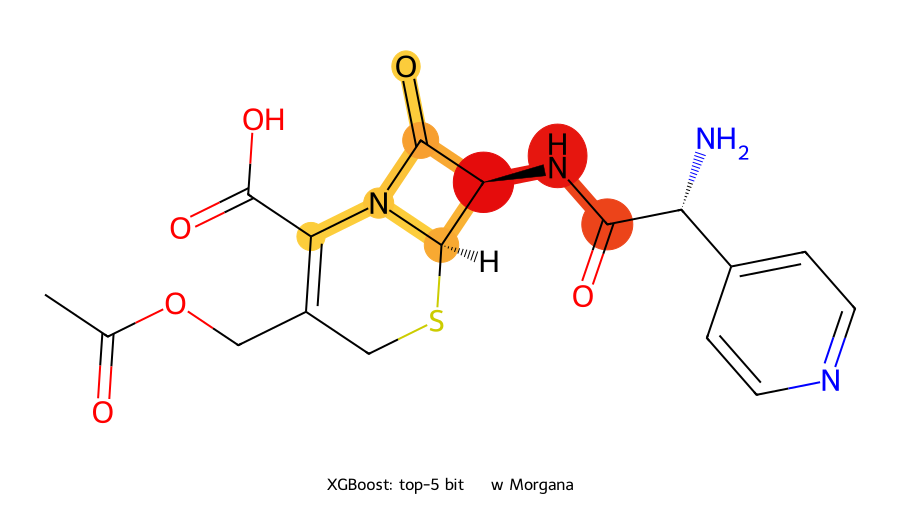

,atom_idx,symbol,score,norm
4,13,C,0.040656,1.000000
5,14,N,0.038762,0.953408
6,15,C,0.029906,0.735590
2,11,C,0.012486,0.307118
7,25,C,0.010592,0.260526
1,10,N,0.005495,0.135162
3,12,O,0.003759,0.092454
0,6,C,0.003601,0.088570


,bond_idx,begin,end,score,norm
4,13,13,14,0.038762,0.953408
5,14,14,15,0.029906,0.735590
3,12,11,13,0.010750,0.264410
6,24,13,25,0.008856,0.217818
1,10,10,11,0.005495,0.135162
2,11,11,12,0.003759,0.092454
0,9,6,10,0.003601,0.088570
7,28,25,10,0.003601,0.088570


In [43]:
from rdkit.Chem.Draw import rdMolDraw2D

atom_scores = {
    atom.GetIdx(): 0.0
    for atom in top_mol.GetAtoms()
}

bond_scores = {
    bond.GetIdx(): 0.0
    for bond in top_mol.GetBonds()
}

for _, row in top_bits.iterrows():
    atoms, bonds = atoms_bonds_for_bit(top_mol, row["bit"], bit_info)
    importance = float(row["importance"])

    for atom_idx in atoms:
        atom_scores[atom_idx] += importance

    for bond_idx in bonds:
        bond_scores[bond_idx] += importance

atom_scores = {
    atom_idx: score
    for atom_idx, score in atom_scores.items()
    if score > 0
}

bond_scores = {
    bond_idx: score
    for bond_idx, score in bond_scores.items()
    if score > 0
}

max_score = max([*atom_scores.values(), *bond_scores.values()])


def heatmap_color(score):
    value = score / max_score if max_score else 0.0
    low = np.array([1.00, 0.88, 0.25])
    high = np.array([0.90, 0.05, 0.05])

    return tuple(low * (1 - value) + high * value)


mol_2d = Chem.Mol(top_mol)
Chem.rdDepictor.Compute2DCoords(mol_2d)

drawer = rdMolDraw2D.MolDraw2DSVG(900, 520)

options = drawer.drawOptions()
options.addAtomIndices = False
options.addStereoAnnotation = False
options.fillHighlights = True

drawer.DrawMolecule(
    mol_2d,
    highlightAtoms=list(atom_scores),
    highlightBonds=list(bond_scores),
    highlightAtomColors={
        atom_idx: heatmap_color(score)
        for atom_idx, score in atom_scores.items()
    },
    highlightBondColors={
        bond_idx: heatmap_color(score)
        for bond_idx, score in bond_scores.items()
    },
    highlightAtomRadii={
        atom_idx: 0.25 + 0.35 * score / max_score
        for atom_idx, score in atom_scores.items()
    },
    legend=f"{importance_model}: top-5 bitów Morgana",
)

drawer.FinishDrawing()
heatmap_svg = drawer.GetDrawingText()

display(SVG(heatmap_svg))

atom_df = (
    pd.DataFrame([
        {
            "atom_idx": atom_idx,
            "symbol": top_mol.GetAtomWithIdx(atom_idx).GetSymbol(),
            "score": score,
            "norm": score / max_score,
        }
        for atom_idx, score in atom_scores.items()
    ])
    .sort_values("score", ascending=False)
)

bond_df = (
    pd.DataFrame([
        {
            "bond_idx": bond_idx,
            "begin": top_mol.GetBondWithIdx(bond_idx).GetBeginAtomIdx(),
            "end": top_mol.GetBondWithIdx(bond_idx).GetEndAtomIdx(),
            "score": score,
            "norm": score / max_score,
        }
        for bond_idx, score in bond_scores.items()
    ])
    .sort_values("score", ascending=False)
)

display(atom_df)
display(bond_df)